In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# %%bash 
# for f in drive/MyDrive/zipped_LOB_data/*; do
#     name=$(basename $f ".7z")
#     mkdir -p "data/extracted/$name"
#     7z x $f -o"data/extracted/$name" -y
# done


In [2]:
# Classical ML vs DeepLOB: can feature engineering + LightGBM/logistic regression
# beat the deep models on the same task?
#
# Ground rules for a fair comparison (identical to Representations_Test.ipynb):
#   - same target: smoothed midprice return over k=100 events, ternary labels
#     from train-set quantiles (0.33 / 0.66)
#   - same sampling: one decision point every 10 events
#   - same split: all days except last 10 for train, next 5 val, last 5 test
#   - strictly causal features: everything at time t uses only data <= t

# %pip install scikit-learn lightgbm   # uncomment on first run

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

from deeplob_library.data import (read_message_file, read_orderbook_file,
                                  combine_message_orderbook,
                                  get_OFI_representation, get_tick_spread_ratio)

import warnings
warnings.filterwarnings("ignore")

DATA_ROOT = Path("data/extracted")
symbol_dirs = sorted(DATA_ROOT.glob("*"))
print("symbols found:", [d.name for d in symbol_dirs])

# Pick one symbol to start; loop over symbol_dirs later once the pipeline works.
SYMBOL_DIR = symbol_dirs[0]

K = 100 
PAST_W,FUTURE_W,SHIFT = 4,50,1        # label horizon / smoothing window (matches get_smoothed_midprice_targets)
TIME_STEP = 10   # sample a decision point every 10 events (matches unfold step)
VAL_DAYS, TEST_DAYS = 5, 5

WINDOWS = (10,25,50,100,500,1000)

def get_engineered_features(df,windows = WINDOWS,n_levels = 10):

    out = pd.DataFrame(index = df.index)
    mid = (df['bid_price_1'] + df['ask_price_1'])/2
    tick  = (df['ask_price_2'] - df['ask_price_1']).abs().replace(0,np.nan).min()

    #family 1 book shape
    out['spread_ticks'] = (df['ask_price_1'] - df['bid_price_1']).abs()/tick

    qb,qa = df['bid_size_1'],df['ask_size_1']
    micro = (df['bid_price_1']*qa + df['ask_price_1']*qb)/(qa+qb)
    out['micro_minus_mid'] = (micro - mid)/tick
    out['imb_1'] = (qb-qa)/(qa+qb)
    #k level imbalances
    for k in (3,5,10):
        b = sum(df[f'bid_size_{i}'] for i in range(1,k+1))
        a = sum(df[f'ask_size_{i}'] for i in range(1,k+1))
        out[f'imb_{k}'] = (b-a)/(b+a)

    bid_depth = sum(df[f'bid_size_{i}'] for i in range(1, n_levels + 1))
    ask_depth = sum(df[f'ask_size_{i}'] for i in range(1, n_levels + 1))

    out['log_bid_depth'] = np.log1p(bid_depth)
    out['log_ask_depth'] = np.log1p(ask_depth)

    out['depth_ratio'] = np.log1p(bid_depth) - np.log1p(ask_depth)
    out['ask_slope'] = ask_depth / ((df[f'ask_price_{n_levels}'] - df['ask_price_1']) / tick + 1)
    out['bid_slope'] = bid_depth / ((df['bid_price_1'] - df[f'bid_price_{n_levels}']) / tick + 1)

    #family 2 price momentum

    ofi = get_OFI_representation(df,n_levels = n_levels)
    level_weights = np.exp(-0.5 * np.arange(n_levels))
    agg_ofi = (ofi * level_weights).sum(axis = 1)
    ofi_touch = ofi['ofi_1']
    for w in windows:
        out[f'ofi_sum_{w}'] = agg_ofi.rolling(w).sum()
        out[f'ofi1_sum_{w}'] = ofi_touch.rolling(w).sum()

    
    
    # ---------- family 3: trade & message flow ----------
    # LOBSTER convention: 'direction' is the side of the LIMIT order, so an
    # execution (type 4/5) against a sell limit (direction = -1) was a BUYER-
    # initiated trade. Hence trade sign = -direction.
    is_trade = df['event_type'].isin([4, 5])
    signed_trade_vol = (-df['direction'] * df['size']).where(is_trade, 0.0)
    # Cancellations (types 2/3) pulling liquidity from the bid are bearish:
    # someone no longer wants to buy at that price.
    is_cancel = df['event_type'].isin([2, 3])
    cancel_bid = (df['size'].where(is_cancel & (df['direction'] == 1), 0.0))
    cancel_ask = (df['size'].where(is_cancel & (df['direction'] == -1), 0.0))
    dt = df['time'].diff()
    for w in windows:
        out[f'trade_flow_{w}'] = signed_trade_vol.rolling(w).sum()
        out[f'trade_count_{w}'] = is_trade.rolling(w).sum()
        out[f'cancel_imb_{w}'] = (cancel_ask - cancel_bid).rolling(w).sum()  # >0 = bullish
        # Event arrival speed: bursts of activity precede moves. Log because
        # inter-arrival times are heavy-tailed.
        out[f'log_dt_mean_{w}'] = np.log1p(dt.rolling(w).mean())


    # ---------- family 4: price dynamics ----------
    # Momentum + volatility of the mid itself. Deep nets get this "for free"
    # from the raw window; we must hand it over explicitly.
    log_mid = np.log(mid)
    ret1 = log_mid.diff()
    for w in windows:
        out[f'ret_{w}'] = log_mid - log_mid.shift(w)             # momentum over w events
        out[f'vol_{w}'] = ret1.rolling(w).std()                  # realized volatility
        out[f'range_{w}'] = (mid.rolling(w).max() - mid.rolling(w).min()) / tick
        out[f'spread_mean_{w}'] = out['spread_ticks'].rolling(w).mean()

        # ---------- family 5: queue dynamics ----------
    # Is the best-bid queue being eaten? Queue depletion at the touch is the
    # mechanical precursor of a price change.
    for w in (10, 50):
        out[f'dq_bid_{w}'] = qb - qb.shift(w)
        out[f'dq_ask_{w}'] = qa - qa.shift(w)
        # how many times the best bid price itself changed in the window
        out[f'bid_px_changes_{w}'] = (df['bid_price_1'].diff() != 0).rolling(w).sum()
        out[f'ask_px_changes_{w}'] = (df['ask_price_1'].diff() != 0).rolling(w).sum()


    return out


# Map each feature to its family, for the ablation later.
FAMILY_PREFIXES = {
    'book_shape':   ('spread_ticks', 'micro_minus_mid', 'imb_', 'log_bid_depth',
                     'log_ask_depth', 'depth_ratio', 'ask_slope', 'bid_slope'),
    'ofi':          ('ofi_',),
    'message_flow': ('trade_', 'cancel_', 'log_dt_'),
    'dynamics':     ('ret_', 'vol_', 'range_', 'spread_mean_'),
    'queue':        ('dq_', 'bid_px_', 'ask_px_'),
}   

symbols found: ['AMD_2026-05-01_2026-05-31_10', 'BAC_2026-05-01_2026-05-31_10', 'MSFT_2026-05-01_2026-05-31_10']


In [3]:
def make_targets(mid, past_window=10, future_window=10, shift=40):
    """
    Smoothed forward-return label, causal at decision time t.

        reference price = trailing mean of `mid` over the last `past_window` events   (known at t)
        future price    = mean of `mid` over `future_window` events, starting `shift` events ahead
        target[t]       = future_price / reference_price - 1

    Parameters
    ----------
    past_window   : events averaged for the reference (denominator), ending at t.
                    Use 1 for "just mid[t]" -> no lookback leakage.
    future_window : events averaged for the forward price (numerator).
                    Smooths bid-ask bounce out of the label.
    shift         : gap (events) between t and the START of the future window.
                    This is the forecast horizon.

    Returns a Series aligned to `mid.index`; warm-up/tail rows are NaN.
    """
    ref = mid.rolling(past_window).mean()                       # trailing, ends at t
    fut = mid.rolling(future_window).mean().shift(-(shift + future_window - 1))
    return fut / ref - 1

def make_labels(target, window, lo_q=0.33, hi_q=0.66, min_periods=None):
    """
    Ternary labels from thresholds computed over the trailing `window` returns.
    Each point is judged against its own recent return distribution.
    0 = down, 1 = flat, 2 = up. NaN where the window isn't warmed up yet.
    """
    if min_periods is None:
        min_periods = window // 4          # allow labels early in the day
    lo = target.rolling(window, min_periods=min_periods).quantile(lo_q)
    hi = target.rolling(window, min_periods=min_periods).quantile(hi_q)

    lab = pd.Series(1.0, index=target.index)   # flat
    lab[target < lo] = 0.0
    lab[target > hi] = 2.0
    lab[lo.isna() | hi.isna()] = np.nan
    return lab

In [4]:
# We bypass get_lists_of_tensors because it drops the message columns before
# we can use them, but we replicate its logic step by step:
#   read -> combine -> target -> (features instead of raw window) -> sample every 10th
def build_day(message_file, orderbook_file):
    """Returns (X: DataFrame of features, y: Series of raw future returns) for one day."""
    df = combine_message_orderbook(read_message_file(message_file),
                                   read_orderbook_file(orderbook_file))
    # Target: identical to get_smoothed_midprice_targets(k=100).
    # Smooth the mid over the past k events, then take the k-events-ahead
    # return of that smoothed series. Smoothing kills bid-ask bounce noise.
    mid = (df['bid_price_1'] + df['ask_price_1']) / 2
    target = make_targets(mid,past_window = PAST_W, future_window = FUTURE_W,shift = SHIFT)
    N = max(int(0.10*len(df)),100)
    target = make_labels(target, window=N, lo_q=0.33, hi_q=0.66)
    feats = get_engineered_features(df)


    # Drop warm-up rows (rolling windows) and tail rows (future target unknown),
    # then keep every TIME_STEP-th row -- same decision-point density as the
    # unfold(0, 100, 10) the deep models use.
    valid = feats.notna().all(axis=1) & target.notna()
    feats, target = feats[valid], target[valid]
    return feats.iloc[::TIME_STEP], target.iloc[::TIME_STEP]



orderbook_files = sorted(SYMBOL_DIR.glob("*orderbook_10.csv"))
message_files = sorted(SYMBOL_DIR.glob("*message_10.csv"))
print(f"{SYMBOL_DIR.name}: {len(orderbook_files)} days, "
      f"tick/spread = {get_tick_spread_ratio(orderbook_files[0], message_files[0]):.3f}")

days_X, days_y = [], []
for mf, of in zip(message_files, orderbook_files):
    X_day, y_day = build_day(mf, of)
    days_X.append(X_day)
    days_y.append(y_day)
    print(f"  {Path(mf).name[:30]}  ->  {len(X_day):,} samples")
feature_names = days_X[0].columns.tolist()
print(f"\n{len(feature_names)} features")




AMD_2026-05-01_2026-05-31_10: 20 days, tick/spread = 0.078
  AMD_2026-05-01_34140000_576600  ->  78,206 samples
  AMD_2026-05-04_34140000_576600  ->  127,406 samples
  AMD_2026-05-05_34140000_576600  ->  142,087 samples
  AMD_2026-05-06_34140000_576600  ->  189,683 samples
  AMD_2026-05-07_34140000_576600  ->  1,091 samples
  AMD_2026-05-08_34140000_576600  ->  111,434 samples
  AMD_2026-05-11_34140000_576600  ->  99,069 samples
  AMD_2026-05-12_34140000_576600  ->  147,614 samples
  AMD_2026-05-13_34140000_576600  ->  74,904 samples
  AMD_2026-05-14_34140000_576600  ->  68,883 samples
  AMD_2026-05-15_34140000_576600  ->  76,071 samples
  AMD_2026-05-18_34140000_576600  ->  88,969 samples
  AMD_2026-05-19_34140000_576600  ->  113,392 samples
  AMD_2026-05-20_34140000_576600  ->  75,742 samples
  AMD_2026-05-21_34140000_576600  ->  74,969 samples
  AMD_2026-05-22_34140000_576600  ->  50,225 samples
  AMD_2026-05-26_34140000_576600  ->  48,400 samples
  AMD_2026-05-27_34140000_576600  -

In [5]:
# Day-level split, same as get_train_val_test_sets: chronological, no shuffling
# across days -- shuffling would leak intraday autocorrelation into the test set.
X_train = pd.concat(days_X[:-VAL_DAYS - TEST_DAYS]).values
X_val = pd.concat(days_X[-VAL_DAYS - TEST_DAYS:-TEST_DAYS]).values
X_test = pd.concat(days_X[-TEST_DAYS:]).values

y_train = pd.concat(days_y[:-VAL_DAYS - TEST_DAYS]).values.astype(int)
y_val   = pd.concat(days_y[-VAL_DAYS - TEST_DAYS:-TEST_DAYS]).values.astype(int)
y_test  = pd.concat(days_y[-TEST_DAYS:]).values.astype(int)

# Standardize with train statistics only (same as normalize_train_val_test).
# Logistic regression needs this; trees don't care but it does no harm.
scaler = StandardScaler().fit(X_train)
X_train_s, X_val_s, X_test_s = map(scaler.transform, (X_train, X_val, X_test))


print(f"train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")
print("test class balance:", np.bincount(y_test) / len(y_test))
# Note: classes are balanced by construction on TRAIN; on test they can drift.
# The majority-class rate on test is the floor any model must beat.




train (1040377, 79), val (429143, 79), test (251423, 79)
test class balance: [0.32683963 0.33751884 0.33564153]


In [6]:
# Linear baseline first. If this already gets close to the deep models, the
# signal is mostly linear in our features and the trees won't add much.
results = {}
logreg = LogisticRegression(max_iter=2000, C=1.0, n_jobs=-1)
logreg.fit(X_train_s, y_train)


def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    results[name] = {'accuracy': acc, 'macro_f1': f1}
    print(f"{name}:  accuracy = {acc:.4f}   macro-F1 = {f1:.4f}")
    return acc, f1


evaluate('logreg (val)', y_val, logreg.predict(X_val_s))
evaluate('logreg (test)', y_test, logreg.predict(X_test_s))



logreg (val):  accuracy = 0.4298   macro-F1 = 0.4292
logreg (test):  accuracy = 0.4201   macro-F1 = 0.4068


(0.42010874104596635, 0.40677669559030183)

In [7]:
# Gradient boosting: captures interactions (e.g. "imbalance matters more when
# the spread is 1 tick") and thresholds that the linear model can't.
# Early stopping on the val days is our regularizer -- LOB data is noisy and
# unconstrained boosting will happily memorize the train days.
lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=3,
    n_estimators=2000,          # generous cap; early stopping picks the real number
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=200,      # large leaves: individual LOB samples are ~pure noise
    subsample=0.8, subsample_freq=1,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    n_jobs=-1,
)
lgbm.fit(
    X_train, y_train,           # trees don't need the scaled version
    eval_set=[(X_val, y_val)],
    eval_metric='multi_logloss',
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)
print(f"\nbest iteration: {lgbm.best_iteration_}")
evaluate('lightgbm (val)', y_val, lgbm.predict(X_val))
evaluate('lightgbm (test)', y_test, lgbm.predict(X_test))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.186933 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17463
[LightGBM] [Info] Number of data points in the train set: 1040377, number of used features: 79
[LightGBM] [Info] Start training from score -1.115928
[LightGBM] [Info] Start training from score -1.094745
[LightGBM] [Info] Start training from score -1.085408
Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.999585
[200]	valid_0's multi_logloss: 0.992751
[300]	valid_0's multi_logloss: 0.990479
[400]	valid_0's multi_logloss: 0.989394
[500]	valid_0's multi_logloss: 0.988709
[600]	valid_0's multi_logloss: 0.988383
[700]	valid_0's multi_logloss: 0.988167
[800]	valid_0's multi_logloss: 0.988073
Early stopping, best iteration is:
[829]	valid_0's multi_logloss: 0.987934

best iteration: 829
lightgbm (val):  accuracy = 0.4960   macro-F1 = 0.4927
lightgbm (test

(0.47118203187457, 0.4470611999464893)

              precision    recall  f1-score   support

        down       0.46      0.60      0.52     82175
        flat       0.50      0.20      0.28     84860
          up       0.47      0.62      0.54     84388

    accuracy                           0.47    251423
   macro avg       0.48      0.47      0.45    251423
weighted avg       0.48      0.47      0.45    251423



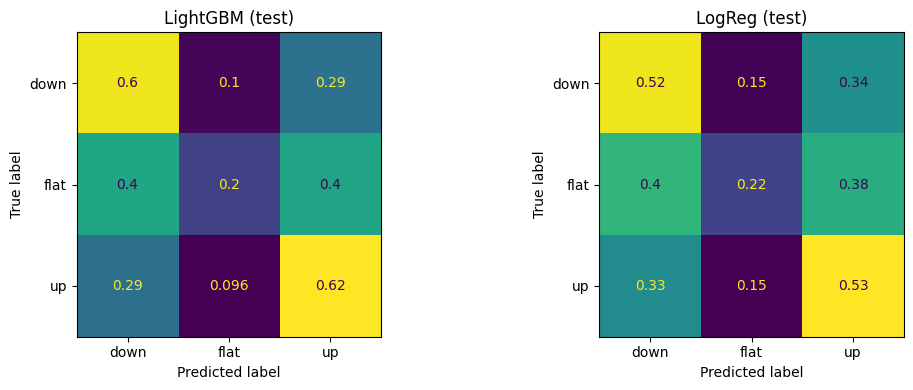

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, lgbm.predict(X_test), ax=axes[0], colorbar=False,
    display_labels=['down', 'flat', 'up'], normalize='true')
axes[0].set_title('LightGBM (test)')
ConfusionMatrixDisplay.from_predictions(
    y_test, logreg.predict(X_test_s), ax=axes[1], colorbar=False,
    display_labels=['down', 'flat', 'up'], normalize='true')
axes[1].set_title('LogReg (test)')
plt.tight_layout()
print(classification_report(y_test, lgbm.predict(X_test),
                            target_names=['down', 'flat', 'up']))

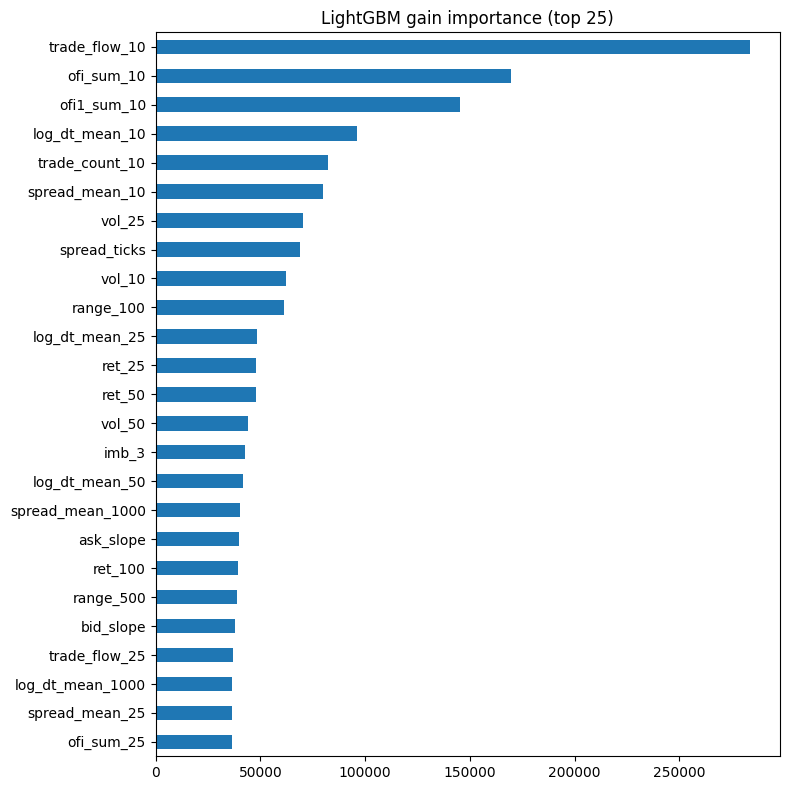

In [9]:
# Gain importance: how much each feature reduced the loss across all splits.
# Cheap but biased toward high-cardinality features -- treat as a first look.
imp = pd.Series(lgbm.booster_.feature_importance('gain'),
                index=feature_names).sort_values(ascending=False)
imp.head(25).plot.barh(figsize=(8, 8))
plt.gca().invert_yaxis()
plt.title('LightGBM gain importance (top 25)')
plt.tight_layout()

In [10]:
# The real question isn't "which single feature" but "which FAMILY of
# information matters". Retrain with one family removed at a time; the drop in
# val accuracy is that family's unique (non-redundant) contribution.
def family_columns(family):
    prefixes = FAMILY_PREFIXES[family]
    return [i for i, f in enumerate(feature_names) if f.startswith(prefixes)]

full_val_acc = results['lightgbm (val)']['accuracy']
print(f"full model val accuracy: {full_val_acc:.4f}\n")

for family in FAMILY_PREFIXES:
    drop = set(family_columns(family))
    keep = [i for i in range(len(feature_names)) if i not in drop]
    m = lgb.LGBMClassifier(objective='multiclass', num_class=3,
                           n_estimators=2000, learning_rate=0.05, num_leaves=63,
                           min_child_samples=200, subsample=0.8, subsample_freq=1,
                           colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1)
    m.fit(X_train[:, keep], y_train, eval_set=[(X_val[:, keep], y_val)],
          eval_metric='multi_logloss',
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    acc = accuracy_score(y_val, m.predict(X_val[:, keep]))
    print(f"without {family:<13} ({len(drop):>2} feats): "
          f"val acc = {acc:.4f}  (Δ = {acc - full_val_acc:+.4f})")

full model val accuracy: 0.4960

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.229215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14834
[LightGBM] [Info] Number of data points in the train set: 1040377, number of used features: 68
[LightGBM] [Info] Start training from score -1.115928
[LightGBM] [Info] Start training from score -1.094745
[LightGBM] [Info] Start training from score -1.085408
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[694]	valid_0's multi_logloss: 0.992096
without book_shape    (11 feats): val acc = 0.4925  (Δ = -0.0034)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.202485 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15933
[LightGBM] [Info] Number of data points in the train set: 1040377, number of used features: 73
[LightGBM] [Info] S

In [11]:
# Train LightGBM on ONE family at a time. Read this together with the drop-one
# ablation: a family can be strong alone but add nothing on top of the others
# (redundant information), or weak alone but irreplaceable (unique information).
#
#   only-family acc high, drop-family Δ ~ 0   -> signal is real but duplicated elsewhere
#   only-family acc low,  drop-family Δ big   -> unique complementary information
#   only-family acc ~ chance                  -> family is dead weight, consider cutting

def make_lgbm():
    # Same hyperparameters as the main model so accuracies are comparable.
    return lgb.LGBMClassifier(objective='multiclass', num_class=3,
                              n_estimators=2000, learning_rate=0.05, num_leaves=63,
                              min_child_samples=200, subsample=0.8, subsample_freq=1,
                              colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1)

full_val_acc = results['lightgbm (val)']['accuracy']
chance = np.bincount(y_val).max() / len(y_val)   # majority-class floor on val
print(f"full model val accuracy: {full_val_acc:.4f}   (chance: {chance:.4f})\n")

only_family_results = {}
for family in FAMILY_PREFIXES:
    cols = family_columns(family)                # reuse helper from the ablation cell
    m = make_lgbm()
    m.fit(X_train[:, cols], y_train,
          eval_set=[(X_val[:, cols], y_val)],
          eval_metric='multi_logloss',
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    acc = accuracy_score(y_val, m.predict(X_val[:, cols]))
    only_family_results[family] = acc
    print(f"only {family:<13} ({len(cols):>2} feats): "
          f"val acc = {acc:.4f}  ({acc - full_val_acc:+.4f} vs full)")

# Side-by-side summary: standalone strength vs unique contribution.
# Assumes the drop-one ablation cell stored its accuracies; if it just printed
# them, either re-read them off that cell's output or store them in a dict there.
summary = pd.DataFrame({
    'n_features': {f: len(family_columns(f)) for f in FAMILY_PREFIXES},
    'only_family_acc': only_family_results,
}).sort_values('only_family_acc', ascending=False)
print("\n", summary.to_string())

full model val accuracy: 0.4960   (chance: 0.3381)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021387 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2629
[LightGBM] [Info] Number of data points in the train set: 1040377, number of used features: 11
[LightGBM] [Info] Start training from score -1.115928
[LightGBM] [Info] Start training from score -1.094745
[LightGBM] [Info] Start training from score -1.085408
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[132]	valid_0's multi_logloss: 1.09129
only book_shape    (11 feats): val acc = 0.3742  (-0.1218 vs full)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002983 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data 

order of addition: dynamics -> message_flow -> ofi -> queue -> book_shape 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.043934 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5378
[LightGBM] [Info] Number of data points in the train set: 1040377, number of used features: 24
[LightGBM] [Info] Start training from score -1.115928
[LightGBM] [Info] Start training from score -1.094745
[LightGBM] [Info] Start training from score -1.085408
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[309]	valid_0's multi_logloss: 1.04713
top-1  ( 24 feats, +dynamics     ): val acc = 0.4409
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.112891 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10659
[LightGBM] [Info] Number of data points in the train set: 1040377, number of used feat

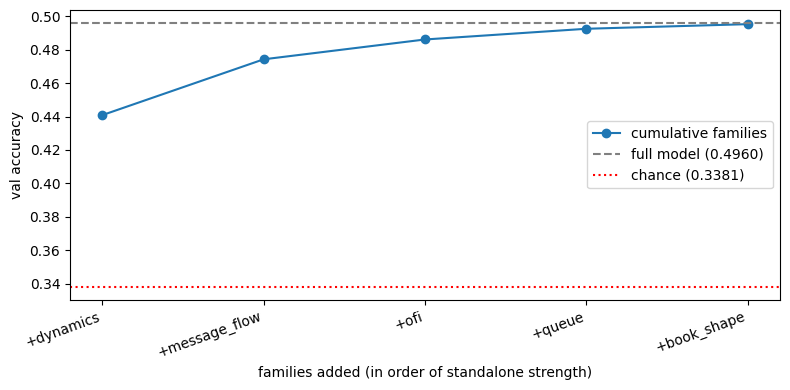

In [12]:
# Forward-additive experiment: rank families by standalone val accuracy, then
# train on top-1, top-2, ..., all 5. Where the curve plateaus tells you the
# minimal feature set; if accuracy ever DROPS when adding a family, that family
# is contributing more noise than signal at this data size.
#
# Caveat: this is greedy ordering by standalone strength, not the true optimal
# subset ordering -- a family that's weak alone but complementary (see the
# drop-one ablation) may look better here than its standalone rank suggests.

ranked_families = sorted(only_family_results, key=only_family_results.get, reverse=True)
print("order of addition:", " -> ".join(ranked_families), "\n")

cumulative_results = {}
cols_so_far = []
for n, family in enumerate(ranked_families, start=1):
    cols_so_far = cols_so_far + family_columns(family)
    m = make_lgbm()
    m.fit(X_train[:, cols_so_far], y_train,
          eval_set=[(X_val[:, cols_so_far], y_val)],
          eval_metric='multi_logloss',
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    acc = accuracy_score(y_val, m.predict(X_val[:, cols_so_far]))
    prev = list(cumulative_results.values())[-1] if cumulative_results else None
    gain = f"  (+{acc - prev:.4f})" if prev is not None else ""
    cumulative_results[f"top-{n} (+{family})"] = acc
    print(f"top-{n:<2} ({len(cols_so_far):>3} feats, +{family:<13}): val acc = {acc:.4f}{gain}")

# Plot the curve with reference lines for the full model and chance level.
fig, ax = plt.subplots(figsize=(8, 4))
accs = list(cumulative_results.values())
ax.plot(range(1, len(accs) + 1), accs, marker='o', label='cumulative families')
ax.axhline(full_val_acc, ls='--', c='gray', label=f'full model ({full_val_acc:.4f})')
ax.axhline(chance, ls=':', c='red', label=f'chance ({chance:.4f})')
ax.set_xticks(range(1, len(ranked_families) + 1))
ax.set_xticklabels([f"+{f}" for f in ranked_families], rotation=20, ha='right')
ax.set_xlabel('families added (in order of standalone strength)')
ax.set_ylabel('val accuracy')
ax.legend()
plt.tight_layout()

base values (down/flat/up): [-1.204 -1.081 -1.156]


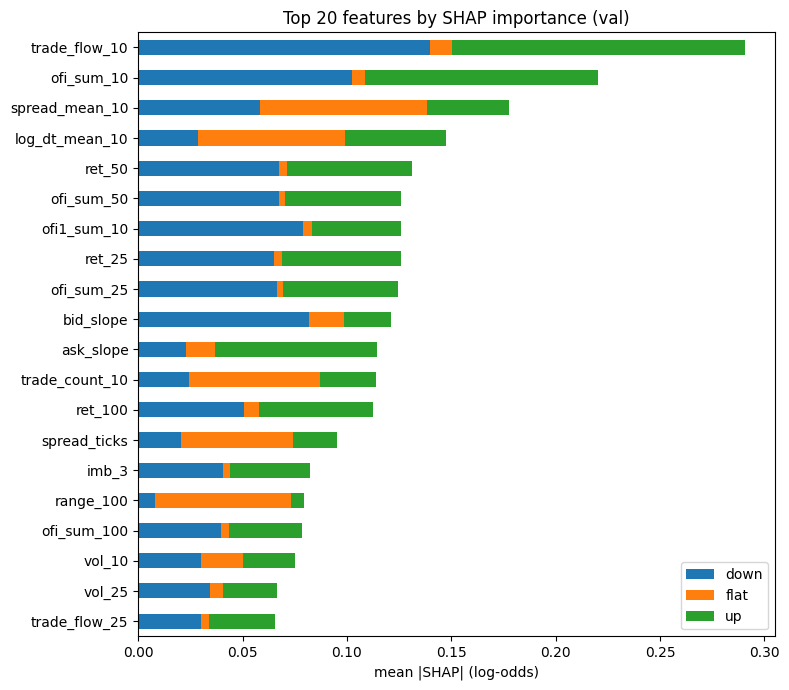

In [13]:
# TreeSHAP contributions: for each sample, each feature's additive push (in raw
# log-odds space) toward each class. Row sums + base value = the model's raw
# score, so these are exact decompositions of each prediction, not heuristics.
#
# We explain the VAL set: train would reflect memorization, and test should
# stay untouched until final evaluation.

rng = np.random.default_rng(0)
N_EXPLAIN = 20_000                      # SHAP output is (n, 3*(F+1)); sample to keep it light
idx = rng.choice(len(X_val), size=min(N_EXPLAIN, len(X_val)), replace=False)
X_expl = X_val[idx]
y_expl = y_val[idx]

raw = lgbm.booster_.predict(X_expl, pred_contrib=True)

# For multiclass, columns are [class0: F features + base, class1: ..., class2: ...]
n_feat = len(feature_names)
contrib = raw.reshape(len(X_expl), 3, n_feat + 1)
shap_vals = contrib[:, :, :-1]          # (n_samples, 3 classes, n_features)
base_vals = contrib[0, :, -1]           # per-class expected value (same for all rows)
print("base values (down/flat/up):", np.round(base_vals, 3))

# Global importance = mean |contribution| across samples, summed over classes.
# Unlike gain importance this is measured on HELD-OUT data, so a feature that
# only helped memorize train days will rank low here.
mean_abs = pd.DataFrame(np.abs(shap_vals).mean(axis=0).T,
                        index=feature_names, columns=['down', 'flat', 'up'])
mean_abs['total'] = mean_abs.sum(axis=1)
top = mean_abs.sort_values('total', ascending=False).head(20)

top[['down', 'flat', 'up']].plot.barh(stacked=True, figsize=(8, 7))
plt.gca().invert_yaxis()
plt.xlabel('mean |SHAP| (log-odds)')
plt.title('Top 20 features by SHAP importance (val)')
plt.tight_layout()

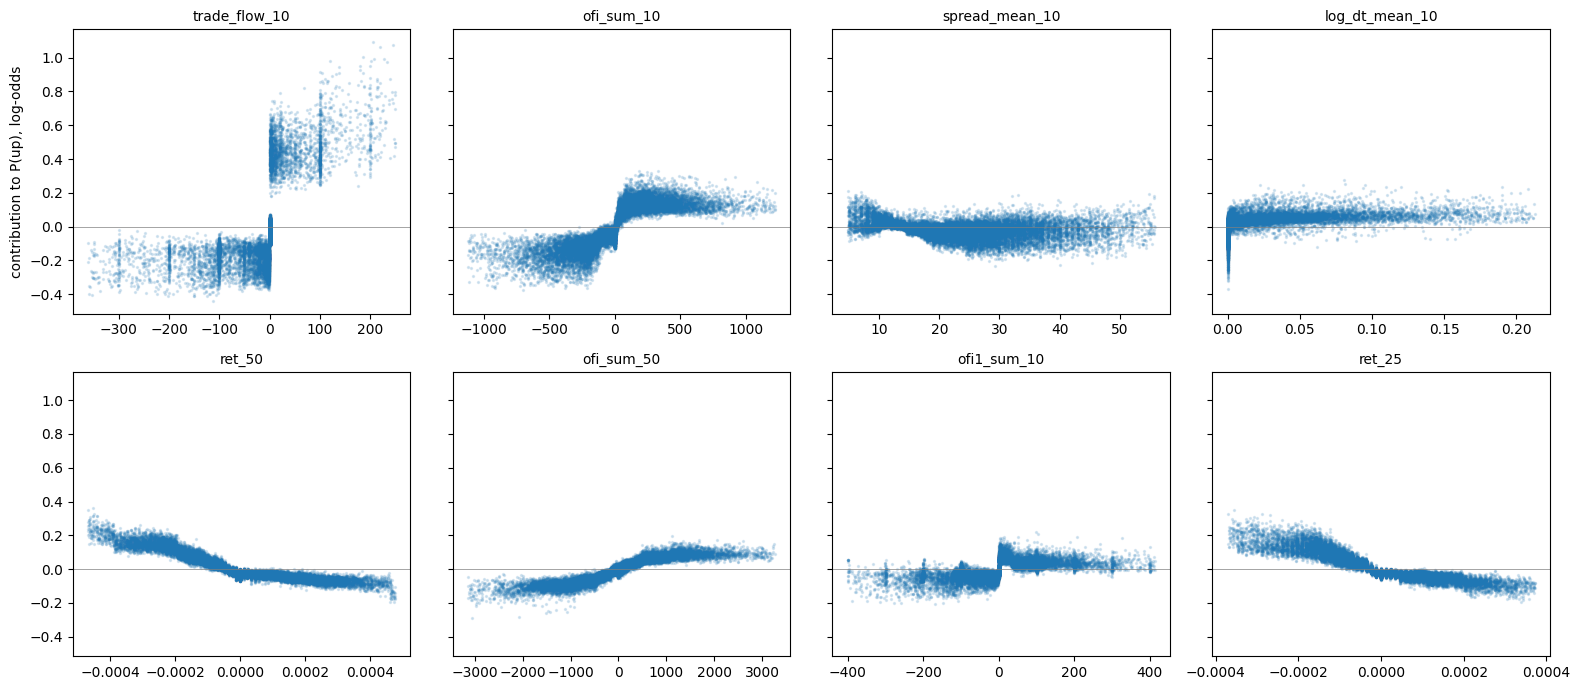

In [14]:
# Dependence plots: feature value (x) vs its contribution to the UP class (y).
# This reveals the SHAPE of each relationship -- linear, saturating, threshold --
# which tells you what LightGBM learned beyond what logistic regression could.
# Expect e.g. imbalance features to saturate (deeply one-sided books aren't
# 2x more predictive than moderately one-sided ones).

UP = 2
top_feats = top.index[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
for ax, feat in zip(axes.ravel(), top_feats):
    j = feature_names.index(feat)
    x = X_expl[:, j]
    # clip x-axis to 1st-99th percentile so outliers don't flatten the plot
    lo_, hi_ = np.percentile(x, [1, 99])
    m = (x >= lo_) & (x <= hi_)
    ax.scatter(x[m], shap_vals[m, UP, j], s=2, alpha=0.15)
    ax.axhline(0, c='gray', lw=0.5)
    ax.set_title(feat, fontsize=10)
axes[0, 0].set_ylabel('contribution to P(up), log-odds')
plt.tight_layout()

# Sanity check on the vertical spread within each plot: points at the same x
# with different y = interaction with other features. A thick vertical band
# means the feature's meaning depends heavily on context (e.g. regime).

interaction strength ranking:
  micro_minus_mid    x spread_ticks       score = 0.223
  cancel_imb_100     x log_dt_mean_100    score = 0.184
  ret_50             x ofi_sum_10         score = 0.170
  ofi_sum_100        x log_ask_depth      score = 0.147
  imb_1              x imb_10             score = 0.129
  ofi_sum_1000       x log_ask_depth      score = 0.121
  ret_100            x vol_100            score = 0.116
  imb_1              x spread_ticks       score = 0.113
  trade_flow_100     x trade_count_100    score = 0.109
  ret_100            x ofi_sum_1000       score = 0.103
  ret_100            x ofi_sum_100        score = 0.090
  ret_1000           x ofi_sum_100        score = 0.087
  ret_1000           x ofi_sum_1000       score = 0.075
  dq_bid_10          x spread_ticks       score = 0.068
  ofi_sum_100        x ofi_sum_1000       score = 0.042


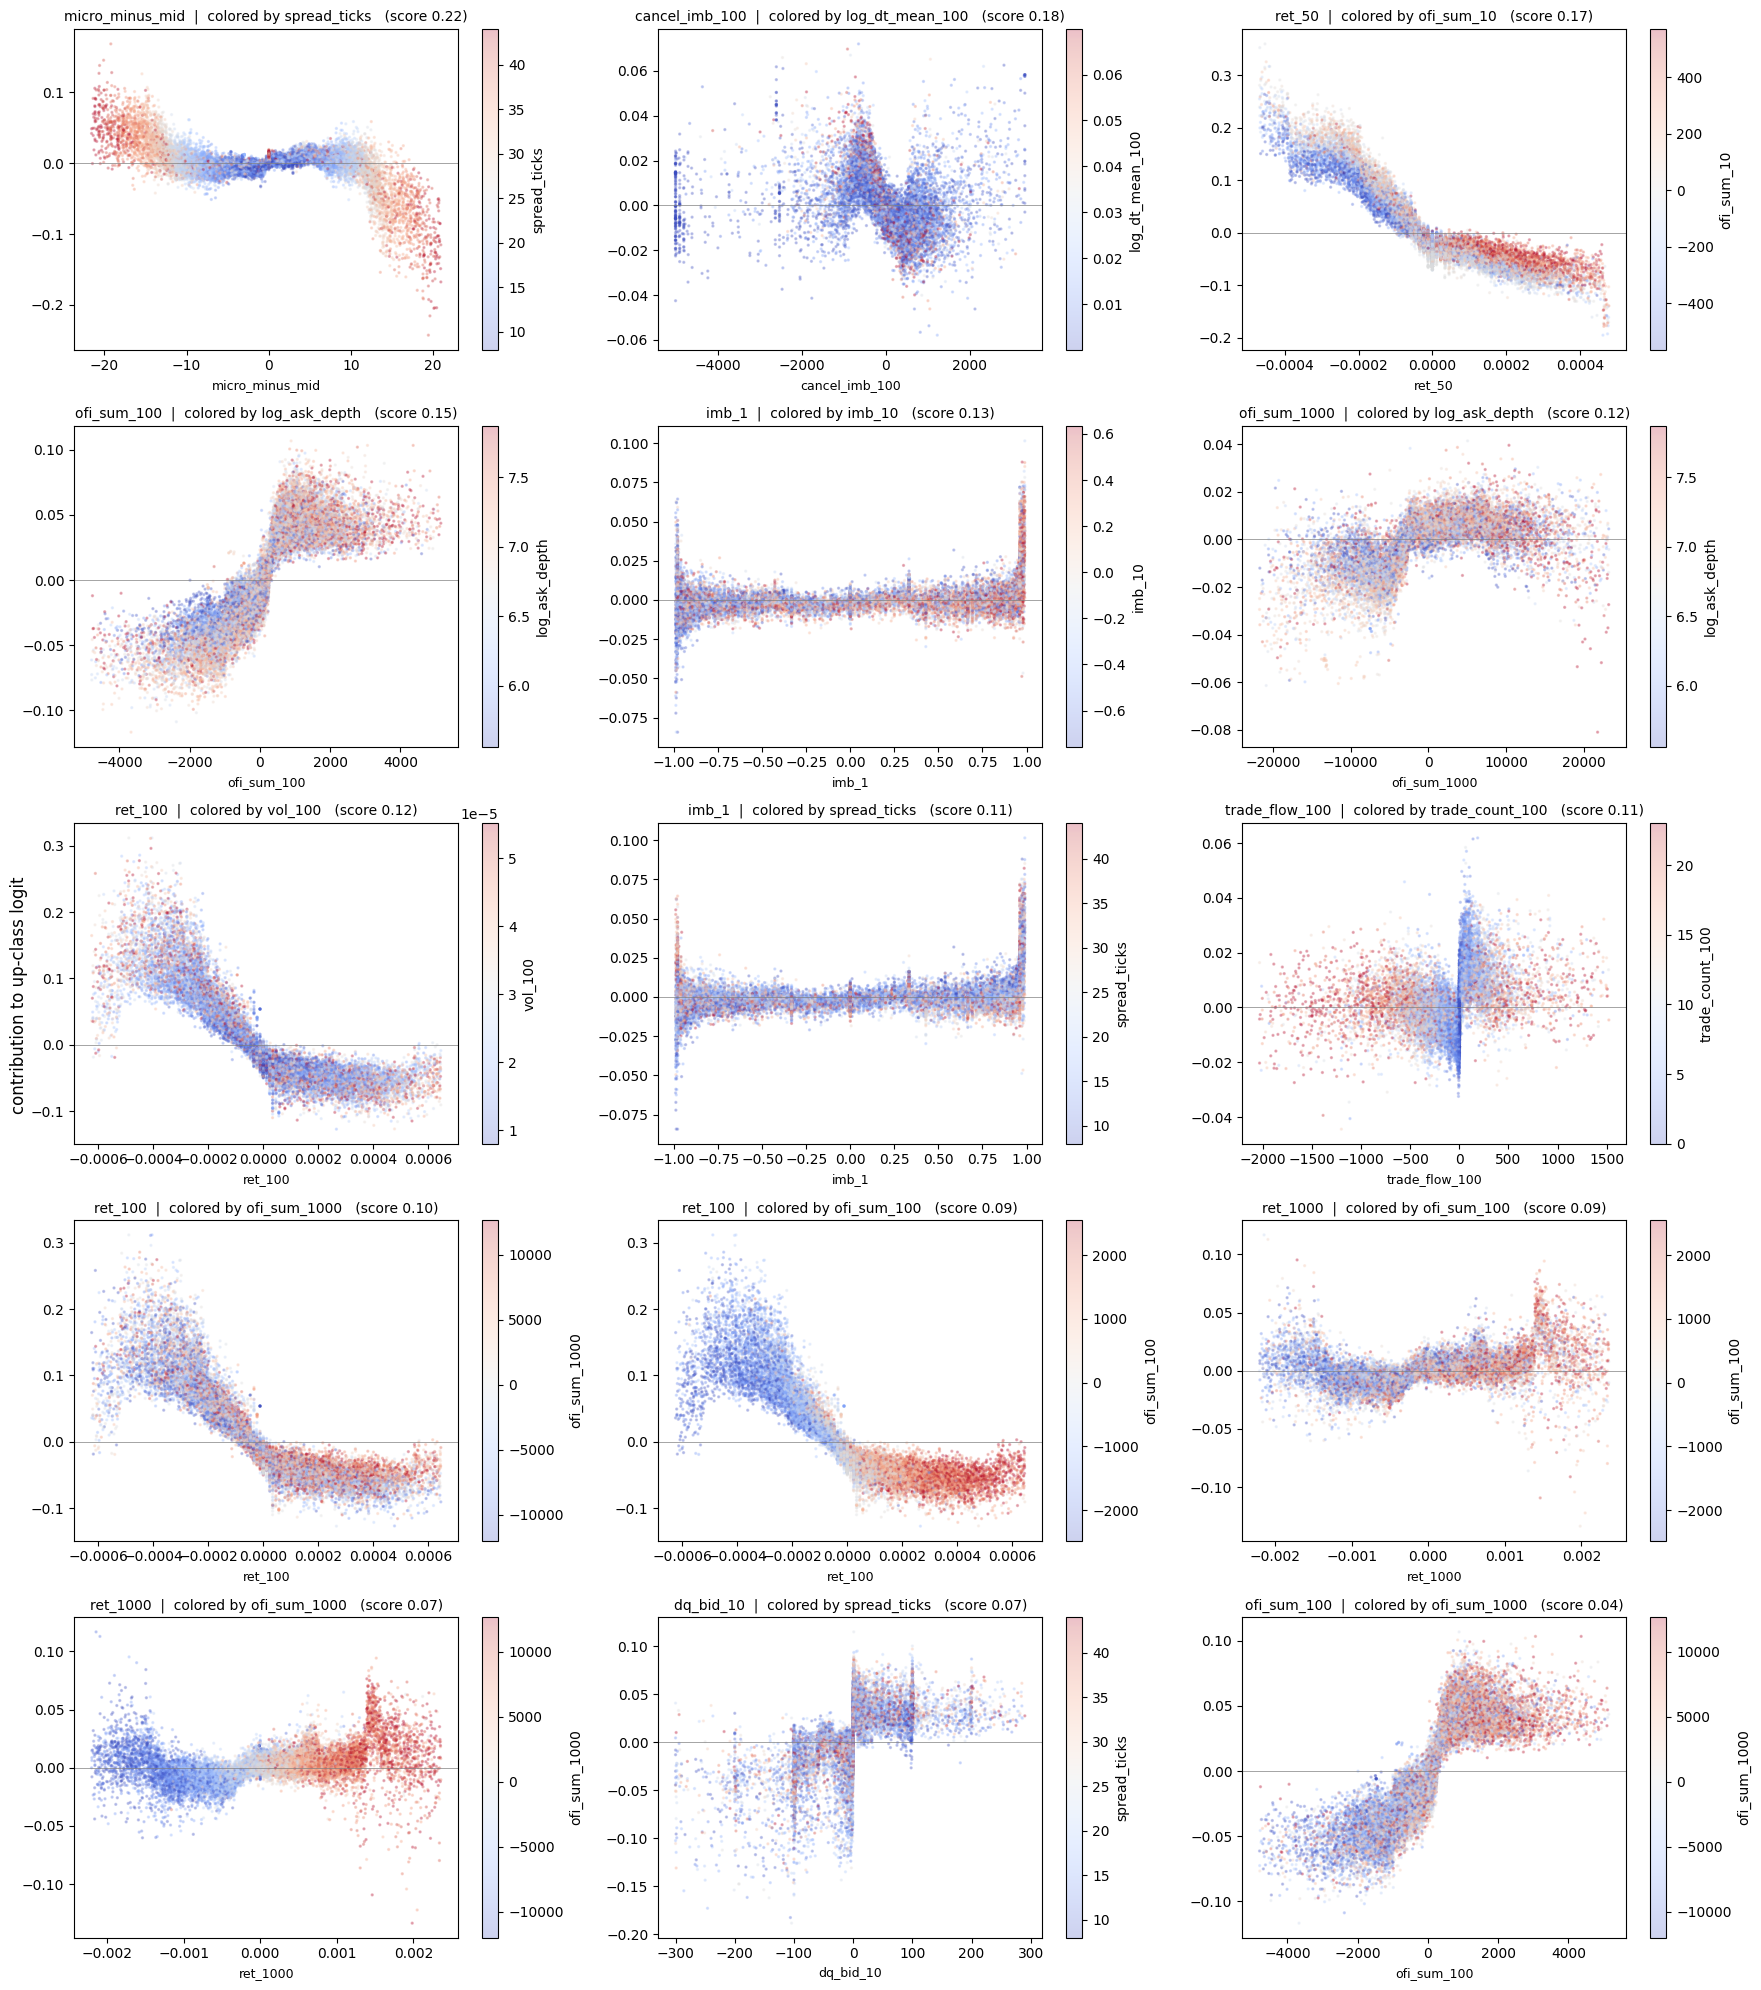

In [15]:
import math
# For each candidate pair (feat, color_feat) we plot feat's SHAP contribution
# vs its value, colored by color_feat. If color separates into distinct bands,
# the model learned an interaction: feat's meaning depends on color_feat.
#
# The score quantifies the same thing: bin feat into deciles, and within each
# bin (i.e. holding feat roughly constant) correlate the leftover vertical
# spread of the SHAP values with color_feat. If the spread is just noise the
# correlation is ~0; if color_feat explains it, |corr| is high. We report the
# sample-weighted mean |corr| across bins: 0 = no interaction, 1 = the vertical
# spread is entirely governed by color_feat.

def interaction_score(feat, color_feat, cls=UP, n_bins=10):
    j, k = feature_names.index(feat), feature_names.index(color_feat)
    x, y, c = X_expl[:, j], shap_vals[:, cls, j], X_expl[:, k]
    bins = pd.qcut(x, n_bins, duplicates='drop')
    df_ = pd.DataFrame({'bin': bins, 'y': y, 'c': c})
    per_bin = df_.groupby('bin').apply(
        lambda g: abs(np.corrcoef(g['c'], g['y'])[0, 1]) if len(g) > 30 else np.nan)
    weights = df_.groupby('bin').size()
    return float((per_bin * weights).sum() / weights[per_bin.notna()].sum())

def plot_shap_interaction(feat, color_feat, ax, cls=UP, clip=(1, 99)):
    j, k = feature_names.index(feat), feature_names.index(color_feat)
    x, y, c = X_expl[:, j], shap_vals[:, cls, j], X_expl[:, k]
    lo_, hi_ = np.percentile(x, clip)
    m = (x >= lo_) & (x <= hi_)
    sc = ax.scatter(x[m], y[m], c=c[m], s=2, alpha=0.25, cmap='coolwarm',
                    vmin=np.percentile(c, 5), vmax=np.percentile(c, 95))
    ax.axhline(0, c='gray', lw=0.5)
    ax.set_xlabel(feat, fontsize=9)
    plt.colorbar(sc, ax=ax, label=color_feat)
    return sc

# --- candidate interactions, each with a hypothesis to confirm or kill ---
PAIRS = [
    # The canonical large-tick effect: when the spread is 1 tick, the next mid
    # move is mechanically gated by queue depletion, so imbalance is highly
    # informative. When the spread is wide, the mid can move without any queue
    # emptying, and imbalance should matter less.
    ('imb_1', 'spread_ticks'),

    # Microprice deviation is bounded by half the spread, so its raw magnitude
    # means something different at different spreads. Expect steeper SHAP
    # slope (per unit of deviation, in ticks) when the spread is tight.
    ('micro_minus_mid', 'spread_ticks'),

    # Price impact of flow scales with available liquidity: the same net OFI
    # should push the logit harder when the book is thin. Kyle-lambda logic.
    ('ofi_sum_100', 'log_ask_depth'),
    ('ofi_sum_1000', 'log_ask_depth'),
    # Momentum vs mean-reversion by regime: does a past up-move predict
    # continuation in quiet markets but reversal in volatile ones?
    ('ret_100', 'vol_100'),

    # A move BACKED by flow should continue; a move WITHOUT flow support
    # (e.g. spread repositioning) should revert. If real, red and blue points
    # will have opposite-signed contributions at the same ret_100.
    ('ret_100', 'ofi_sum_100'),
    ('ret_1000', 'ofi_sum_1000'),
    ('ret_100', 'ofi_sum_1000'),
    ('ret_1000', 'ofi_sum_100'),
    ('ofi_sum_100', 'ofi_sum_1000'),
    ('ret_100', 'ofi_sum_100'),

    # Same net traded volume from many small trades vs a few large ones.
    # Many-small = algorithmic slicing (informed, persistent); few-large =
    # one-off liquidity demand. Tests whether the model distinguishes them.
    ('trade_flow_100', 'trade_count_100'),

    # Queue depletion at the best bid only matters if the price is ABOUT to
    # tick, i.e. when the spread is already tight. At wide spreads a shrinking
    # bid queue is routine churn.
    ('dq_bid_10', 'spread_ticks'),

    # Touch imbalance confirmed (or contradicted) by the deep book. A one-sided
    # touch backed by a one-sided deep book is conviction; touch-only imbalance
    # is often fleeting quote flicker.
    ('imb_1', 'imb_10'),

    # Cancellation pressure during activity bursts (small dt) is liquidity
    # fleeing ahead of a move; the same cancellations in calm conditions are
    # routine requoting. If the model uses this, colors separate.
    ('cancel_imb_100', 'log_dt_mean_100'),
    ('ret_50','ofi_sum_10')
]

# rank pairs by interaction score, then plot in that order
scores = {(f, c): interaction_score(f, c) for f, c in PAIRS}
ranked = sorted(scores, key=scores.get, reverse=True)
print("interaction strength ranking:")
for f, c in ranked:
    print(f"  {f:<18} x {c:<18} score = {scores[(f, c)]:.3f}")

n = len(ranked)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
for ax, (f, c) in zip(axes.ravel(), ranked):
    plot_shap_interaction(f, c, ax)
    ax.set_title(f"{f}  |  colored by {c}   (score {scores[(f, c)]:.2f})", fontsize=10)
for ax in axes.ravel()[n:]:
    ax.axis('off')
fig.supylabel('contribution to up-class logit')
plt.tight_layout()

#save the plot
plt.savefig('shap_interaction_plot.png')


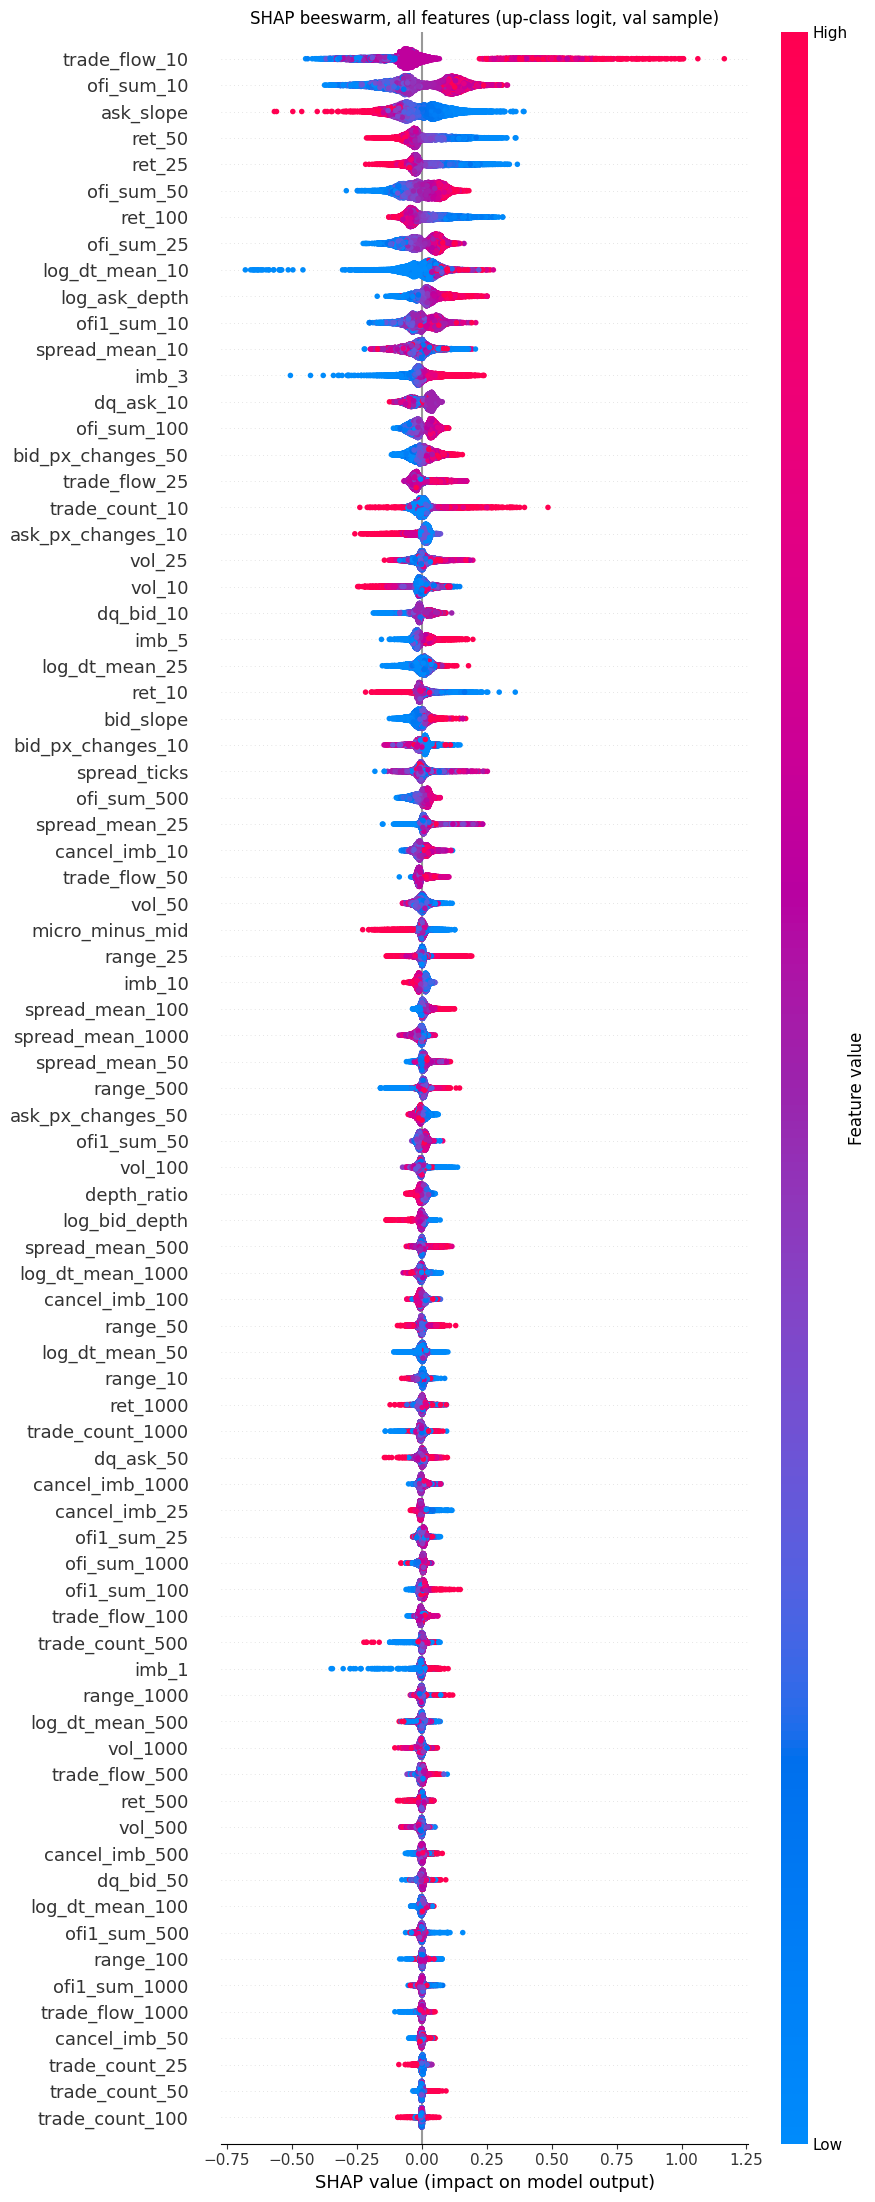

In [16]:
import shap

# Beeswarm for ALL features, up-class contributions.
# Each row = feature (sorted by mean |SHAP|), each dot = one sample,
# x = contribution to the up logit, color = the feature's own value.
#
# What to scan for, row by row:
#   - clean red/blue separation along x  -> simple monotonic effect
#   - color mixed at the same x          -> interactions (dig with dependence plots)
#   - long one-sided tail                -> feature fires rarely but hard (event-like)
#   - symmetric blob around 0            -> dead weight candidate
#
# 10k dots per row is plenty for the visual; more just slows rendering.
n_plot = 10_000
#create random sample of 10k
rng = np.random.default_rng(0)
sub = rng.choice(len(X_expl), size=min(n_plot, len(X_expl)), replace=False)
X_expl_df = pd.DataFrame(X_expl[sub], columns=feature_names)

shap.summary_plot(
    shap_vals[sub, 2, :],            # up class
    X_expl_df,
    max_display=len(feature_names),  # default is 20 -- override to show everything
    show=False,                      # let us control the figure before it renders
)
fig = plt.gcf()
fig.set_size_inches(9, 0.28 * len(feature_names))   # ~0.28in per row keeps rows legible
plt.title('SHAP beeswarm, all features (up-class logit, val sample)')
plt.tight_layout()
plt.show()

      n_trades  mid_to_mid (ticks)  net (ticks)  hit rate  spread cost (ticks)  t_stat (optimistic)
hold                                                                                               
50      218024              2.1989     -18.8501    0.0340              21.0489            -669.3440
100     218002              2.6501     -18.4272    0.0937              21.0773            -552.0466
200     217953              3.2010     -17.8706    0.1798              21.0716            -409.2766
500     217823              3.7668     -17.2782    0.3052              21.0450            -244.9889
1000    217611              3.9656     -17.0695    0.3644              21.0351            -164.9318


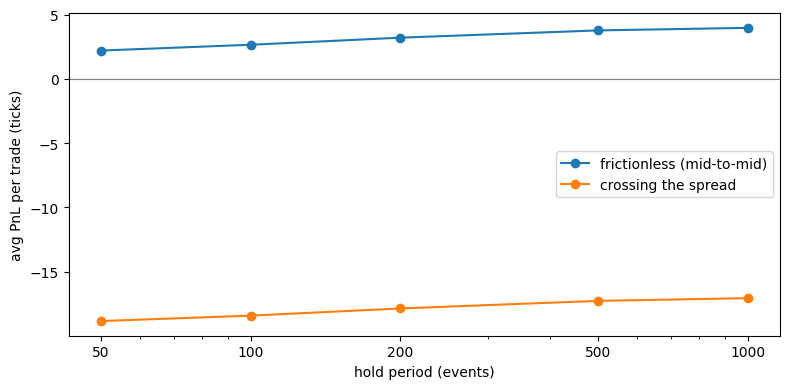

In [17]:
# We need full-resolution bid/ask series for the TEST days (days_X only keeps
# every 10th row of features, no prices), plus the integer position of each
# decision point so we can index "k events later".
HOLD_PERIODS = [50, 100, 200, 500, 1000]

def build_day_for_sim(message_file, orderbook_file):
    df = combine_message_orderbook(read_message_file(message_file),
                                   read_orderbook_file(orderbook_file))
    # replicate build_day's validity mask exactly so features align with prices
    mid = (df['bid_price_1'] + df['ask_price_1']) / 2
    target = make_targets(mid,past_window = PAST_W, future_window = FUTURE_W,shift = SHIFT)
    N = max(int(0.10 * len(df)), 100)
    labels = make_labels(target, window=N)
    feats  = get_engineered_features(df)
    valid  = (feats.notna().all(axis=1) & labels.notna()).values   # must match build_day
    pos = np.flatnonzero(valid)[::TIME_STEP]      # decision points, as row numbers
    gap = (df['ask_price_2'] - df['ask_price_1']).abs().replace(0, np.nan)
    return (feats.values[pos], pos,
            df['bid_price_1'].values, df['ask_price_1'].values, gap.min())

sim_days = [build_day_for_sim(mf, of)
            for mf, of in zip(message_files[-TEST_DAYS:], orderbook_files[-TEST_DAYS:])]

rows = []
for k_hold in HOLD_PERIODS:
    pnl_net, pnl_mid = [], []
    for X_day, pos, bid, ask, tick in sim_days:
        pred = lgbm.predict(X_day)
        ok = pos + k_hold < len(bid)                # trade must fit inside the day
        p, pr = pos[ok], pred[ok]
        lo_, sh = pr == 2, pr == 0                  # up -> long, down -> short, flat -> no trade

        net = np.zeros(len(p))                      # spread-crossing PnL
        net[lo_] = bid[p + k_hold][lo_] - ask[p][lo_]     # buy ask, sell bid later
        net[sh] = bid[p][sh] - ask[p + k_hold][sh]        # sell bid, buy ask later

        mid_now = (bid[p] + ask[p]) / 2
        mid_exit = (bid[p + k_hold] + ask[p + k_hold]) / 2
        fric = np.where(lo_, mid_exit - mid_now, np.where(sh, mid_now - mid_exit, 0.0))

        traded = lo_ | sh
        pnl_net.append(net[traded] / tick)          # everything in ticks
        pnl_mid.append(fric[traded] / tick)

    pnl_net, pnl_mid = np.concatenate(pnl_net), np.concatenate(pnl_mid)
    # t-stat of the mean: with overlapping trades it's OPTIMISTIC (correlated
    # samples), so treat it as an upper bound on significance.
    tstat = pnl_net.mean() / (pnl_net.std() / np.sqrt(len(pnl_net)))
    rows.append({'hold': k_hold, 'n_trades': len(pnl_net),
                 'mid_to_mid (ticks)': pnl_mid.mean(),
                 'net (ticks)': pnl_net.mean(),
                 'hit rate': (pnl_net > 0).mean(),
                 'spread cost (ticks)': pnl_mid.mean() - pnl_net.mean(),
                 't_stat (optimistic)': tstat})

sim = pd.DataFrame(rows).set_index('hold')
print(sim.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sim.index, sim['mid_to_mid (ticks)'], marker='o', label='frictionless (mid-to-mid)')
ax.plot(sim.index, sim['net (ticks)'], marker='o', label='crossing the spread')
ax.axhline(0, c='gray', lw=0.8)
ax.set_xscale('log'); ax.set_xticks(HOLD_PERIODS); ax.set_xticklabels(HOLD_PERIODS)
ax.set_xlabel('hold period (events)'); ax.set_ylabel('avg PnL per trade (ticks)')
ax.legend(); plt.tight_layout()

In [18]:
# Sweep the confidence threshold at each hold period. Signal strength should
# be monotone in model confidence if the probabilities mean anything.
THRESHOLDS = [0.34, 0.40, 0.45, 0.50, 0.60,0.75,0.9]

rows = []
for k_hold in HOLD_PERIODS:
    for tau in THRESHOLDS:
        pnl_net = []
        for X_day, pos, bid, ask, tick in sim_days:
            proba = lgbm.predict_proba(X_day)
            ok = pos + k_hold < len(bid)
            p, pb = pos[ok], proba[ok]
            lo_ = (pb[:, 2] > tau) & (pb.argmax(1) == 2)
            sh = (pb[:, 0] > tau) & (pb.argmax(1) == 0)
            net = np.zeros(len(p))
            net[lo_] = bid[p + k_hold][lo_] - ask[p][lo_]
            net[sh] = bid[p][sh] - ask[p + k_hold][sh]
            pnl_net.append(net[lo_ | sh] / tick)
        pnl_net = np.concatenate(pnl_net) if pnl_net else np.array([np.nan])
        rows.append({'hold': k_hold, 'tau': tau,
                     'n_trades': len(pnl_net), 'net (ticks)': np.nanmean(pnl_net)})

conf = pd.DataFrame(rows).pivot(index='tau', columns='hold', values='net (ticks)')
print("avg net PnL per trade (ticks):\n", conf.round(4).to_string())
print("\ntrade counts:\n",
      pd.DataFrame(rows).pivot(index='tau', columns='hold', values='n_trades').to_string())

avg net PnL per trade (ticks):
 hold     50       100      200      500      1000
tau                                              
0.34 -18.8433 -18.4194 -17.8604 -17.2631 -17.0499
0.40 -18.4669 -17.9966 -17.3560 -16.6672 -16.4186
0.45 -17.9791 -17.4206 -16.6912 -15.8598 -15.4961
0.50 -17.4662 -16.8081 -15.9698 -14.9249 -14.4704
0.60 -16.3724 -15.5911 -14.5066 -13.0769 -12.4395
0.75 -14.6932 -13.7771 -12.4241 -10.6014  -9.5140
0.90 -13.1402 -12.4771 -10.6646  -7.8488  -6.7836

trade counts:
 hold    50      100     200     500     1000
tau                                         
0.34  217616  217594  217545  217415  217203
0.40  180712  180695  180658  180548  180377
0.45  131974  131961  131931  131855  131735
0.50   92317   92311   92289   92240   92166
0.60   43308   43307   43297   43273   43233
0.75   11447   11447   11442   11436   11428
0.90    1113    1113    1112    1111    1109
